In [1]:
import os
import cv2
import torch
import numpy as np 
import pandas as pd 
import matplotlib
import matplotlib.pyplot as plt 
from matplotlib.patches import Rectangle
from tqdm import tqdm
import wandb
from datetime import datetime

import snntorch as snn
from snntorch import surrogate
import snntorch.functional as SF
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from torchinfo import summary

# clean gpu memory when starting a new evaluation.
torch.cuda.empty_cache()

GPU_DEVICE = 3
os.environ['CUDA_VISIBLE_DEVICES'] = str(GPU_DEVICE)
os.environ['CUDA_LAUNCH_BLOCKING'] = str(1)

assert torch.cuda.is_available()

DEVICE = torch.device(f"cuda") if torch.cuda.is_available() else torch.device("cpu")
assert DEVICE == torch.device(f"cuda"), f'{DEVICE}'

In [2]:
def seed_everything(seed=42):
    #random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)
    print(f"Global seed set to {seed}")

In [3]:
DATA_PATH = 'data/events_converted_from_3D_models/mug'
event_lst = sorted([f for f in os.listdir(DATA_PATH) if '.npy' in f])
RES = (260, 356)

In [4]:
from PIL import Image

def create_gif(images, output_gif_path, duration=100):
     images = [Image.fromarray(np.stack([img, img, img], axis=-1)) for img in images]
     # Save as GIF
     images[0].save(output_gif_path,
                    save_all=True,
                    append_images=images[1:],
                    duration=duration,
                    loop=0 # 0 means infinite loop
                    )

test = np.load(os.path.join(DATA_PATH, event_lst[0]))
frames = np.zeros((35, *RES))

all_times = []
for t in test:
    x, y, pol, time = t 
    
    all_times.append(time // 1000)
    t = time // 1000 
    frames[t, y, x] = pol if pol > 0 else 0.5
    
frames = frames * 255
create_gif(frames.astype(np.uint8), 'test.gif')

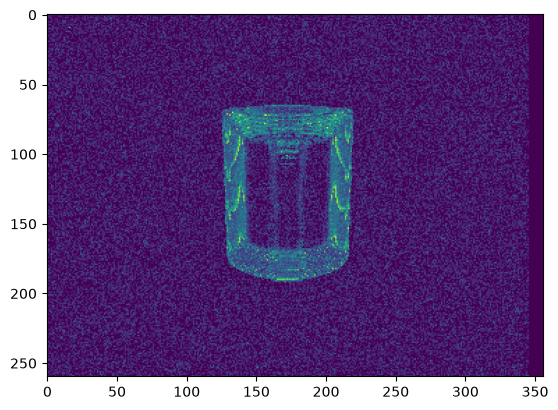

In [5]:
import tonic
T = tonic.transforms.ToFrame(sensor_size=(356, 260, 2), n_time_bins=35)
frame = T(test)
plt.imshow(frame.mean(axis=(0, 1)))

## Read CALTECH 256

```python
%%time
import h5py

filename = "data/INI_Caltech256_10fps_20160424.hdf5"
data_lst = []
with h5py.File(filename, "r") as f:

    #f.visit(print)  
    object_keys = f.keys()
    for k in object_keys:
        sample_lst = f[k].keys()
        
        for s in sample_lst:
            data_x = f[k][s]['x_pos'][:]
            data_y = f[k][s]['y_pos'][:]
            data_t = f[k][s]['timestamps'][:]
            data_pol = f[k][s]['pol'][:]
            
            data = {'object': k, 'sample': s, 'x_pos': data_x, 'y_pos': data_y, 
                    'timestamps': data_t, 'pol': data_pol}
            data_lst.append(data)
        
    
df = pd.DataFrame.from_records(data_lst)
df['category'] = df.apply(lambda x: int(x['object'].split('.')[0]), axis=1)
df['label'] = df.apply(lambda x: str(x['object'].split('.')[1]), axis=1)
df['sample'] = df['sample'].map(lambda x: int(x.split('_')[-1]))
del df['object']
df.to_pickle('Caltech_256_DVS.pkl')
df.head() 
```

In [6]:
df = pd.read_pickle('data/Caltech_256_DVS.pkl')
print('Number of samples: ', len(df))
df.head()

Number of samples:  30607


,sample,x_pos,y_pos,timestamps,pol,category,label
0,1,"[192, 146, 106, 37, 140, 80, 87, 173, 146, 187...","[109, 71, 29, 101, 36, 143, 135, 88, 50, 153, ...","[288080, 288235, 288387, 288692, 289515, 28971...","[True, True, True, True, True, True, True, Tru...",1,ak47
1,2,"[152, 149, 224, 76, 80, 63, 213, 38, 214, 135,...","[53, 116, 18, 114, 8, 173, 102, 23, 104, 28, 3...","[299585, 301461, 301791, 304118, 304755, 30783...","[True, True, True, True, True, True, True, Tru...",1,ak47
2,3,"[80, 128, 94, 57, 113, 105, 91, 96, 166, 93, 1...","[144, 40, 149, 37, 62, 44, 59, 32, 89, 142, 12...","[299761, 299961, 300369, 300463, 300466, 30046...","[True, True, True, True, True, True, True, Tru...",1,ak47
3,4,"[208, 40, 94, 191, 104, 158, 126, 138, 48, 214...","[97, 142, 137, 96, 136, 29, 56, 147, 75, 121, ...","[301202, 302304, 302330, 304919, 304952, 30559...","[True, True, True, True, True, True, True, Tru...",1,ak47
4,5,"[108, 154, 220, 162, 215, 124, 132, 86, 220, 2...","[122, 179, 84, 126, 31, 135, 155, 104, 12, 73,...","[286731, 286909, 288470, 291223, 291830, 29219...","[True, True, True, True, True, True, True, Tru...",1,ak47


In [7]:
idx = 6210 
data = df.iloc[idx]

frames = np.zeros(((max(data.timestamps) // 30000) +1, 180, 240))
for (x, y, pol, time) in zip(data.x_pos, data.y_pos, data.pol, data.timestamps): 
    
    t = time // 30000  
    frames[t, y, x] = pol 
    
frames = frames * 255
create_gif(frames.astype(np.uint8), f'caltech256-{idx}.gif')

In [8]:
import tonic
from torchvision import transforms

class CaltechDataset(Dataset):
    """Caltech 256 DVS Dataset for object recognition
    see DVSACT16 for details https://sensors.ini.ch/datasets
    """

    def __init__(self, dataset, img_size=(180, 240), time_bins=35, transform=None):
        
        self.dataset = dataset
        self.img_size = img_size
        self.time_bins = time_bins
        self.dimension = img_size[0] * img_size[1]
        self.pos_id = np.arange(img_size[0] * img_size[1]).reshape(img_size[0], img_size[1])
        self.tonic_transform = tonic.transforms.ToFrame(sensor_size=(*img_size[::-1], 1), n_time_bins=time_bins)
        self.transform = transform
        
        
    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        data = self.dataset.iloc[idx]
        pol, time = data.pol, data.timestamps 
        cat, label = data.category, data.label
        
        x_col = data.x_pos.astype('<i2')
        y_col = self.img_size[0] - data.y_pos.astype('<i2') - 1 # flip y-axis
        p_col = np.where(data.pol, data.pol, 1).astype('i1') # turn all polarities to positive
        t_col = data.timestamps.astype('<i8')

        # Stack them into a structured array
        events = np.rec.fromarrays([x_col, y_col, p_col, t_col], dtype=[('x', '<i2'), ('y', '<i2'), ('p', 'i1'), ('t', '<i8')])
        
        # turn events into frame with tonic 
        frame = self.tonic_transform(events)
        frame = np.moveaxis(frame.squeeze(), 0, -1) # reshape frame for torchvision transforms
        
        if self.transform: 
            frame = self.transform(frame)
            
        return {'frame': frame, 'cat': int(cat)-1, 'label': label}

cowboy-hat 50 torch.Size([35, 48, 48])


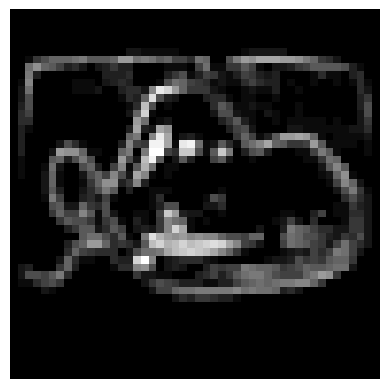

In [9]:
T = transforms.Compose([transforms.ToTensor(),
                        transforms.Pad((0, 30, 0, 30)), #left, top, right, bottom
                        transforms.Resize((48, 48), interpolation=transforms.InterpolationMode.BILINEAR)])

dataset = CaltechDataset(df, transform=T)
sample = dataset.__getitem__(5789)
print(sample['label'], sample['cat'], sample['frame'].shape)

plt.imshow(sample['frame'].float().sum(axis=0), cmap='gray')
plt.axis('off')
plt.show()

## Define Model 

In [30]:
class TinyConvSNN_24_FC(nn.Module):
    def __init__(self, H=48, W=48, n_classes=257, beta=0.95, num_steps=100, dropout_p=0.0, fc_hidden=512):
        super().__init__()
        self.H, self.W = H, W
        self.n_classes = n_classes
        self.num_steps = num_steps
        
        spike_grad = surrogate.fast_sigmoid(slope=25)
        
        # Conv layer (L1)
        self.conv1 = nn.Conv2d(1, 4, kernel_size=5, stride=6, padding=0, bias=False)
        
        # Hidden layer (L2)
        self.fc1 = nn.Linear(256, fc_hidden, bias=False)  
        self.lif_fc1 = snn.Leaky(beta=beta, spike_grad=spike_grad, learn_beta=False)  
        self.dropout_fc1 = nn.Dropout(p=dropout_p)  
        
        # Readout layer (L3)
        self.readout = nn.Linear(fc_hidden, n_classes, bias=False)  
        
        # LIF neurons
        self.lif1 = snn.Leaky(beta=beta, spike_grad=spike_grad, learn_beta=False)
        self.lif_out = snn.Leaky(beta=beta, spike_grad=spike_grad, learn_beta=False)
        
        self.dropout1 = nn.Dropout(p=dropout_p)
        self.dropout_readout = nn.Dropout(p=dropout_p)
        
        self._initialize_weights()
    
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                nn.init.xavier_normal_(m.weight, gain=1.0)
    
    def forward(self, x):
        T, B, _ = x.shape
        x = x.view(T, B, 1, self.H, self.W)
        
        assert 'cuda' in str(x.device)
        
        mem1 = self.lif1.init_leaky().to(x.device)
        mem_fc1 = self.lif_fc1.init_leaky().to(x.device)  
        memo = self.lif_out.init_leaky().to(x.device)
        
        fmap1_rec = []
        spk_out_rec = []
        for t in range(T):
            xt = x[t]
            # Conv layer
            cur1 = self.conv1(xt)
            spk1, mem1 = self.lif1(cur1, mem1)
            spk1 = self.dropout1(spk1)
            
            fmap1_rec.append(spk1)
            
            # Flatten
            feat = spk1.flatten(1)  # [B, 256]
            # Hidden FC layer 
            cur_fc1 = self.fc1(feat)
            spk_fc1, mem_fc1 = self.lif_fc1(cur_fc1, mem_fc1)
            spk_fc1 = self.dropout_fc1(spk_fc1)
            # Readout layer
            spk_fc1_drop = self.dropout_readout(spk_fc1)
            cur_out = self.readout(spk_fc1_drop)
            spk_out, memo = self.lif_out(cur_out, memo)
            
            assert 'cuda' in str(spk_fc1_drop.device)
            assert 'cuda' in str(cur_out.device)
            assert 'cuda' in str(spk_out.device)
            assert 'cuda' in str(memo.device)
            
            spk_out_rec.append(spk_out)
        
        return torch.stack(spk_out_rec, dim=0), [torch.stack(fmap1_rec, dim=0)]
    
    @torch.no_grad()
    def predict(self, x):
        # x: [T,B,2304]
        spk = self.forward(x)
        counts = spk.sum(0)              # [B,26]
        return counts.argmax(dim=1)
    
    
class SpikingObjectClassifier(nn.Module):
    
    def __init__(self, in_channels=1, img_size=(48, 48), hidden=[1, 2],
                 hidden_channels=4, kernel=3, stride=1, padding=1, extra_linear=True,
                 surro='fast_sigmoid', beta=0.5, num_steps=35, batch_size=8,
                 n_classes=257, dropout=None):
        super().__init__()
        
        self.num_steps = num_steps
        self.batch_size = batch_size
        self.extra_linear = extra_linear
        
        # surrogate gradient
        spike_grad = getattr(surrogate, surro)()
        
        self.conv1 = nn.Conv2d(1, hidden_channels*hidden[0], kernel, stride, padding)
        self.lif1 = snn.Leaky(beta=beta, spike_grad=spike_grad)
        
        self.conv2 = nn.Conv2d(hidden_channels*hidden[0], hidden_channels*hidden[1], kernel, stride*hidden[1], padding)
        self.lif2 = snn.Leaky(beta=beta, spike_grad=spike_grad)
        
        self.lif_out = snn.Leaky(beta=beta, spike_grad=spike_grad)
        self.pool = nn.AvgPool2d(kernel_size=2) # maxpooling is unsuitable for SNNs
        
        # use dropout as regularization 
        self.dropout = nn.Dropout(p=dropout) if dropout else None
            
        # flatten before linear layer
        self.fc = nn.Flatten()
        
        hidden_dim = self._get_hidden_dim(torch.ones(1, num_steps, *img_size))
        
        # define classifier
        self.classifier = nn.Linear(hidden_dim, n_classes)
        self.linear = nn.Linear(n_classes, n_classes) if self.extra_linear else None
        
    def _get_hidden_dim(self, x):
        cur1 = self.conv1(x[:, 0].unsqueeze(1))
        cur2 = self.conv2(cur1)
        out = self.fc(cur2)
        return out.shape[-1]
    
    def forward(self, x):
        B, T, H, W = x.shape
        
        # Initialize hidden states and outputs at t=0
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem_out = self.lif_out.init_leaky()
        
        fmap1_rec = []
        fmap2_rec = []
        
        spk_out_rec = []
        mem_out_rec = []
        for step in range(T):
            
            cur1 = self.conv1(x[:, step].unsqueeze(1))
            spk1, mem1 = self.lif1(cur1, mem1)
            
            fmap1_rec.append(spk1)

            cur2 = self.conv2(spk1) #self.pool
            spk2, mem2 = self.lif2(cur2, mem2)
            
            fmap2_rec.append(spk2)
            
            spk_out = self.fc(spk2) #self.pool
            
            spk_out = self.classifier(spk_out)
            
            spk_out, mem_out = self.lif_out(spk_out, mem_out)
            
            if self.extra_linear:
                spk_out = self.linear(spk_out)
                spk_out, mem_out = self.lif_out(spk_out, mem_out)
            
            spk_out_rec.append(spk_out)
            mem_out_rec.append(mem_out)
        
        return torch.stack(spk_out_rec, dim=0), [torch.stack(fmap1_rec, dim=0), torch.stack(fmap2_rec, dim=0)]

In [31]:
#model = TinyConvSNN_24_FC(H=48, W=48, n_classes=257)
model = SpikingObjectClassifier(img_size=(48, 48), n_classes=26, extra_linear=True)
summary(model, input_size=(1, 1, 48, 48))

Layer (type:depth-idx)                   Output Shape              Param #
SpikingObjectClassifier                  [1, 1, 26]                --
├─Conv2d: 1-1                            [1, 4, 48, 48]            40
├─Leaky: 1-2                             [1, 4, 48, 48]            --
├─Conv2d: 1-3                            [1, 8, 24, 24]            296
├─Leaky: 1-4                             [1, 8, 24, 24]            --
├─Flatten: 1-5                           [1, 4608]                 --
├─Linear: 1-6                            [1, 26]                   119,834
├─Leaky: 1-7                             [1, 26]                   --
├─Linear: 1-8                            [1, 26]                   702
├─Leaky: 1-9                             [1, 26]                   --
Total params: 120,872
Trainable params: 120,872
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.38
Input size (MB): 0.01
Forward/backward pass size (MB): 0.11
Params size (MB): 0.48
Estimated Total Size (M

In [32]:
DEBUG = False
RANDOM_SEED = 7
seed_everything(RANDOM_SEED)

LR = 3e-3
EPOCHS = 200
BATCH_SIZE = 512

x = datetime.now()
TIME_STAMP = x.strftime("%d%b%y-%H%M%S")
MODEL_NAME = f"Spiking-RoDeO_{RANDOM_SEED}_{TIME_STAMP}"
print(MODEL_NAME)

T = transforms.Compose([transforms.ToTensor(),
                        transforms.Pad((0, 30, 0, 30)), #left, top, right, bottom
                        transforms.Resize((48, 48), interpolation=transforms.InterpolationMode.BILINEAR)])

dataset = CaltechDataset(df, transform=T)

train_set, val_set = torch.utils.data.random_split(dataset, [int(len(dataset) * 0.8), len(dataset) - int(len(dataset) * 0.8)])
val_set, test_set = torch.utils.data.random_split(val_set, [int(len(val_set) * 0.8), len(val_set) - int(len(val_set) * 0.8)])
print('Training samples: ',len(train_set))
print('Validation samples: ', len(val_set))
print('Test samples: ', len(test_set))

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=16)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE//2, shuffle=False, num_workers=8)

sample = next(iter(val_loader))
sample.keys()

Global seed set to 7
Spiking-RoDeO_7_22Jun26-064328
Training samples:  24485
Validation samples:  4897
Test samples:  1225


dict_keys(['frame', 'cat', 'label'])

In [33]:
if not DEBUG:
    # Initialize wandb 
    wandb.init(project='RoDeO',
               name=MODEL_NAME,
               config={'optimizer': 'AdamW', 
                       'lr': LR, 
                       'loss': 'CrossEntropy',
                       'epochs': EPOCHS,
                       'batch_size': BATCH_SIZE})

spike_grad = surrogate.fast_sigmoid(slope=25)

# initialize loss function & optimizer
loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1) 

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,              # Moderate starting LR
    betas=(0.9, 0.999),
    eps=1e-8,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=5,
    T_mult=2,
    eta_min=2e-7
)

#model = TinyConvSNN_24_FC(H=48, W=48, n_classes=26)
model = SpikingObjectClassifier(img_size=(48,48), n_classes=26)

model.to(DEVICE)

for epoch in range(EPOCHS):
    
    model.train()
    train_loss = []
    train_accuracy = []
    
    pbar = tqdm(train_loader, desc=f'Epoch {epoch}', unit='batch', ncols=115)
    for i, sample in enumerate(pbar):
        B, T, H, W = sample['frame'].shape
        frames = sample['frame'].float().view(B, T, H, W).to(DEVICE)
        #frames = sample['frame'].float().view(T, B, -1).to(DEVICE)
        cats = sample['cat'].to(DEVICE) // 10

        spk_out, _ = model(frames)
        logits = spk_out.sum(0) # [B,C]
        
        #focal loss
        probs = torch.softmax(logits, dim=1)
        loss = loss_fn(probs, cats)
        loss.backward()
        optimizer.step()
        
        # log train loss 
        train_loss.append(loss.item())
        
        # compute train accuracy
        _, predicted = torch.max(logits, 1) ## To get the labels of predicted 
        accuracy = (predicted == cats).sum().item()
        train_accuracy.append(accuracy / B)
        
        pbar.set_postfix(loss=f'{loss.item():.3f}', acc=f'{accuracy / B:.2%}')
    
    pbar.set_postfix(loss=f'{np.mean(train_loss):.3f}', acc=f'{np.mean(train_accuracy):.2%}')
    if not DEBUG:
        # only log once per epoch for faster training
        wandb.log({'loss': np.mean(train_loss), 'accuracy': np.mean(train_accuracy), 'epoch': epoch}) 
    
    # Validation
    model.eval()
    val_loss = []
    val_accuracy = []
    with torch.no_grad():
        for i, sample  in enumerate(val_loader):
            B, T, H, W = sample['frame'].shape
            frames = sample['frame'].float().view(B, T, H, W).to(DEVICE)
            #frames = sample['frame'].float().view(T, B, -1).to(DEVICE)
            cats = sample['cat'].to(DEVICE) // 10

            spk_out, _ = model(frames)
            logits = spk_out.sum(0) # [B,C]

            # compute loss
            probs = torch.softmax(logits, dim=1)
            loss = loss_fn(probs, cats)
            val_loss.append(loss.item())
            
            # compute validation accuracy
            _, predicted = torch.max(logits, 1) ## To get the labels of predicted 
            accuracy = (predicted == cats).sum().item()
            val_accuracy.append(accuracy / B)
    
    print(f'validation loss: {np.mean(val_loss):.2f} - accuracy {np.mean(val_accuracy):.2%}')
    if not DEBUG:
        # log validation metrics to wandb
        wandb.log({'val_loss': np.mean(val_loss), 'val_accuracy': np.mean(val_accuracy), 'epoch': epoch}) 
    
    scheduler.step()
    print(f"New LR: {scheduler.get_last_lr()[0]:.6f}")
    
if not DEBUG:
    wandb.finish() 

accuracy,▃▆▆▆▅▁█
epoch,▁▁▂▂▃▃▅▅▆▆▇▇██
loss,▁▁▁▁▁▁▁
val_accuracy,▁▁▁▁▁▁▁
val_loss,▁▁▁▁▁▁▁
accuracy,0.04068
epoch,6
loss,3.2581
val_accuracy,0.03941
val_loss,3.2581


Epoch 0: 100%|███████████████████████████████████████████| 48/48 [00:28<00:00,  1.69batch/s, acc=4.51%, loss=3.258]


validation loss: 3.26 - accuracy 3.94%
New LR: 0.002714


Epoch 1: 100%|███████████████████████████████████████████| 48/48 [00:27<00:00,  1.77batch/s, acc=3.80%, loss=3.258]


validation loss: 3.26 - accuracy 3.94%
New LR: 0.001964


...

validation loss: 3.26 - accuracy 3.94%
New LR: 0.000287


Epoch 4: 100%|███████████████████████████████████████████| 48/48 [00:28<00:00,  1.71batch/s, acc=4.28%, loss=3.258]


validation loss: 3.26 - accuracy 3.94%
New LR: 0.003000


Epoch 5: 100%|███████████████████████████████████████████| 48/48 [00:28<00:00,  1.68batch/s, acc=3.80%, loss=3.258]


KeyboardInterrupt: 

## Check feature maps

In [34]:
model.eval()
sample = next(iter(val_loader))

#frames = sample['frame'].float().to(DEVICE)

B, T, H, W = sample['frame'].shape
#frames = sample['frame'].float().view(T, B, -1).to(DEVICE)
frames = sample['frame'].float().to(DEVICE)

cats = sample['cat'].to(DEVICE) // 10

spk_out, fmaps = model(frames)
logits = spk_out.sum(0) # [B,C]

# compute loss
probs = torch.softmax(logits, dim=1)
loss = loss_fn(probs, cats)

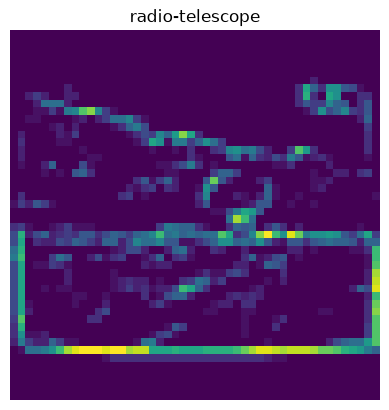

Convolution Layer 1


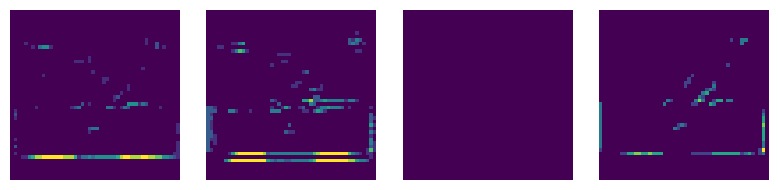

Convolution Layer 2


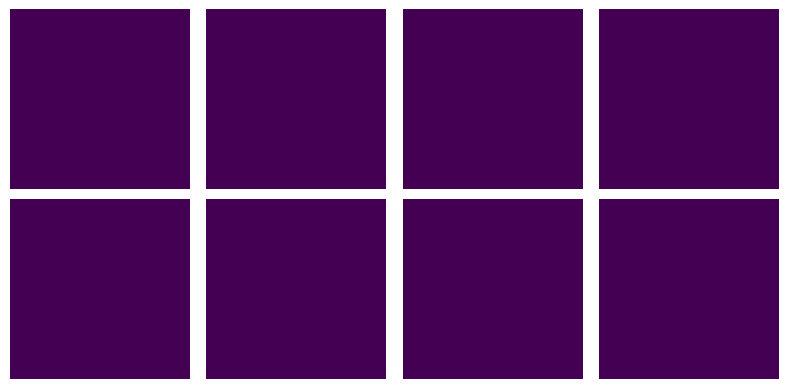

In [35]:
idx = 10
label = sample['label'][idx]

plt.imshow(sample['frame'].float()[idx].mean(0))
plt.axis('off')
plt.title(label)
plt.show()

all_feature_maps = fmaps[0].mean(dim=0)[idx, :, :, :].squeeze().cpu().detach().numpy()

print('Convolution Layer 1')
fig, axs = plt.subplots(1, 4, sharey=True, sharex=True, figsize=(8, 2))
counter = 0
for j in range(4):
    #print(all_feature_maps[counter].min(), all_feature_maps[counter].max())
    axs[j].imshow(all_feature_maps[counter])
    axs[j].axis('off')
    counter += 1
        
plt.axis('off')
plt.tight_layout()
plt.show()

if len(fmaps) > 1:

    all_feature_maps = fmaps[1].mean(dim=0)[idx, :, :, :].squeeze().cpu().detach().numpy()

    print('Convolution Layer 2')

    fig, axs = plt.subplots(2, 4, sharey=True, sharex=True, figsize=(8, 4))
    counter = 0
    for i in range(2):
        for j in range(4):
            #print(all_feature_maps[counter].min(), all_feature_maps[counter].max())
            axs[i, j].imshow(all_feature_maps[counter])
            axs[i, j].axis('off')
            counter += 1

    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [ ]:
spk_out.sum(0)[idx]